In [194]:
import tensorflow as tf
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense

In [195]:
#initialize the model
model = Sequential()

In [196]:
model.add(Dense(4, activation='relu',input_shape = (2,1))) #input layer
# hidden layer
model.add(Dense(3, activation = 'relu'))
#output layer
model.add(Dense(1, activation= 'sigmoid')) 

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [197]:
model.compile(
    optimizer = 'adam', # optimize the weight/mistakes
    loss = 'binary_crossentropy', # cross entropy used for binary classifiocation
    metrics = ['accuracy']) # evaluate performance

In [198]:
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_38 (Dense)                │ (None, 2, 4)           │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 2, 3)           │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 2, 1)           │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27 (108.00 B)

 Trainable params: 27 (108.00 B)

 Non-trainable params: 0 (0.00 B)

In [199]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
import pandas as pd
from gensim.models import Word2Vec

In [200]:
# Sample data 
texts = [
    "I love germany",
    "people are nice here",
    "work culture is good",
    "This country is amazing",
    "Very good climate",
    "Excellent cities",
    "I hate the france",
    "Terrible country",
    "Very boring places",
    "Worst place ever",
    "The country has both good and bad aspects",
    "Some people love it, others hate it",
    "Nice scenery but expensive prices",
    "Good food but poor public transport",
    "Beautiful cities with some crime issues",
    "Amazing culture yet challenging bureaucracy"
]

In [201]:
import gensim.downloader as api

# Download pretrained model
# Trained by Google on a large corpus of news articles
# About 3 million words and phrases
# Trained on roughly 100 billion words from Google News
# Vector size = 300 dimensions
# Around 1.5 GB in memory

model = api.load("word2vec-google-news-300")

In [202]:
model = Word2Vec(
    sentences=texts,     # tokenized sentences
    vector_size=50,          # size of word vector
    window=2,                # context window size
    min_count=1,             # include all words
    workers=1,               # number of CPU threads
    sg=1                     # 1 = Skip-gram, 0 = CBOW
)
model
# # BAG OF WORDS
# vectorizer_bow = CountVectorizer()
# vectorizer_bow.fit(texts)

# X_texts = vectorizer_bow.transform(texts)

# bow_df = pd.DataFrame(
#     columns=texts
# )
# print(bow_df)
# print()


In [203]:
labels = np.array([
    1, 1, 1, 1,
    1, 1, 0, 0,
    0, 0, 2, 2,
    2, 2, 2, 2
]) # labels 1 stand for positive, 0 for negative and 2 for neutral sentence

In [204]:
vectorizer = TfidfVectorizer()

In [205]:
vectorizer = TfidfVectorizer()
X_sparse = vectorizer.fit_transform(texts)  # Returns sparse matrix

# Convert sparse matrix to dense array, then to DataFrame
X = pd.DataFrame(
    X_sparse.toarray(),  # Call toarray() on the sparse matrix
    columns=vectorizer.get_feature_names_out()
)

print(X)

     amazing       and       are   aspects       bad  beautiful    boring  \
0   0.000000  0.000000  0.000000  0.000000  0.000000    0.00000  0.000000   
1   0.000000  0.000000  0.533241  0.000000  0.000000    0.00000  0.000000   
2   0.000000  0.000000  0.000000  0.000000  0.000000    0.00000  0.000000   
3   0.492713  0.000000  0.000000  0.000000  0.000000    0.00000  0.000000   
4   0.000000  0.000000  0.000000  0.000000  0.000000    0.00000  0.000000   
5   0.000000  0.000000  0.000000  0.000000  0.000000    0.00000  0.000000   
6   0.000000  0.000000  0.000000  0.000000  0.000000    0.00000  0.000000   
7   0.000000  0.000000  0.000000  0.000000  0.000000    0.00000  0.000000   
8   0.000000  0.000000  0.000000  0.000000  0.000000    0.00000  0.602102   
9   0.000000  0.000000  0.000000  0.000000  0.000000    0.00000  0.000000   
10  0.000000  0.381602  0.000000  0.381602  0.381602    0.00000  0.000000   
11  0.000000  0.000000  0.000000  0.000000  0.000000    0.00000  0.000000   

In [206]:
X

,amazing,and,are,aspects,bad,beautiful,boring,both,bureaucracy,but,...,some,terrible,the,this,transport,very,with,work,worst,yet
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000,0.000000
1,0.000000,0.000000,0.533241,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.57559,0.00000,0.000000
3,0.492713,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.565768,0.000000,0.000000,0.00000,0.00000,0.00000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.579302,0.00000,0.00000,0.00000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.548943,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000,0.000000
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.788786,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.602102,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.524354,0.00000,0.00000,0.00000,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.57735,0.000000


In [207]:
from tensorflow.keras.layers import Input
model = Sequential([
    Input(shape=(X.shape[1],)),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')  # 3 classes
])

In [208]:
# Compile the model for multi classification
# model.compile(
#     optimizer='adam', 
#     loss='binary_crossentropy',
#     metrics=['accuracy']
# )

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # For integer labels 0,1,2
    metrics=['accuracy']
)
model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_41 (Dense)                │ (None, 8)              │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 427 (1.67 KB)

 Trainable params: 427 (1.67 KB)

 Non-trainable params: 0 (0.00 B)

In [209]:
# Train the model
history = model.fit(X, labels,
          epochs=1500, #number of times the model will see the entire dataset
          verbose=0) #verbose=0 means no output during training

In [210]:
new_text = [
    "Amazing country and good people",
    "Terrible experience, never again",
    "Some good, some bad aspects",
    "I love the culture here",
    "Worst vacation ever"
]
new_vector = vectorizer.transform(new_text).toarray()
prediction = model.predict(new_vector)

print("\nPrediction probabilities:", prediction[0])
# prediction[0] = [prob_negative, prob_neutral, prob_positive]

predicted_class = np.argmax(prediction[0])  # Get the class with highest probability

if predicted_class == 0:
    print("Negative Review")
elif predicted_class == 1:
    print("Positive Review")
else:  # predicted_class == 2
    print("Neutral Review")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

Prediction probabilities: [0.00422201 0.71502537 0.2807526 ]
Positive Review


In [211]:
import matplotlib.pyplot as plt

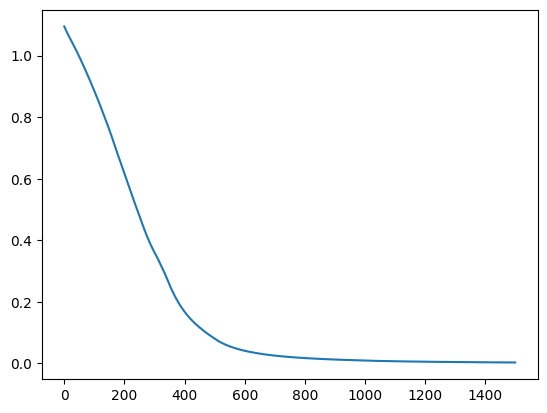

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


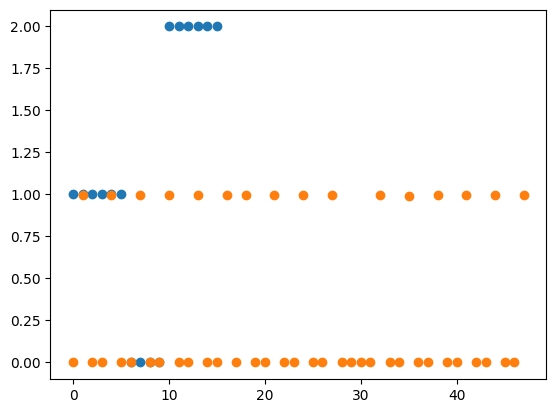

In [212]:
plt.plot(history.history['loss'])
plt.show()
predictions = model.predict(X).flatten()
plt.scatter(range(len(labels)), labels)
plt.scatter(range(len(predictions)), predictions)
plt.show()